<a href="https://colab.research.google.com/github/ev-roso/IS-4487/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS4487 Week 10 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data
3. Fit a model
4. Test the accuracy of the model
6.  Use the model to predict on a new dataset (without the target)

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

### AdviseInvest Data Dictionary


| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| customer_id | Unique customer identifier | Numeric | |
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |

### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [2]:
#Import libraries  🔧
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Step 1: Initial Data Understanding

### Do the following:
 - Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to the DataSets folder and look for `adviseinvest_historical_data.csv`)
 - Describe or profile the dataframe
 - Look for any outliers, missing values, or duplicates

In [7]:
#Import the data 🔧
df = pd.read_csv('adviseinvest_historical_data (1).csv')

In [8]:
#View the datatypes 🔧
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     29504 non-null  int64  
 1   answered        29504 non-null  int64  
 2   income          29504 non-null  int64  
 3   female          29504 non-null  object 
 4   age             29504 non-null  int64  
 5   job             29504 non-null  int64  
 6   num_dependents  29504 non-null  int64  
 7   rent            29504 non-null  int64  
 8   own_res         29504 non-null  int64  
 9   new_car         29502 non-null  float64
 10  chk_acct        29504 non-null  int64  
 11  sav_acct        29504 non-null  int64  
 12  num_accts       29504 non-null  int64  
 13  mobile          29504 non-null  int64  
 14  product         29504 non-null  int64  
dtypes: float64(1), int64(13), object(1)
memory usage: 3.4+ MB
None


In [9]:
#Describe the data 🔧
print(df.describe())

        customer_id      answered         income           age           job  \
count  29504.000000  29504.000000   29504.000000  29504.000000  29504.000000   
mean   14850.475563      0.546638   33766.893303     34.773454      1.915401   
std     8517.254310      0.497829   29379.202710     11.369865      0.658183   
min       99.000000      0.000000  -65600.000000     19.000000      0.000000   
25%     7474.750000      0.000000   13550.000000     26.000000      2.000000   
50%    14850.500000      1.000000   23310.000000     32.000000      2.000000   
75%    22226.250000      1.000000   41690.000000     40.000000      2.000000   
max    29602.000000      1.000000  159450.000000    132.000000      3.000000   

       num_dependents          rent       own_res       new_car      chk_acct  \
count    29504.000000  29504.000000  29504.000000  29502.000000  29504.000000   
mean         1.140998      0.210412      0.681128      0.240797      1.468547   
std          0.348025      0.407608 

## Step 2: Data Preparation

### 2.1: Data Cleanup
- Check for and remove any outliers
- Consider fixing any missing data (should you delete the record or impute the value?)
- Clean up the data and put it in a new dataframe named "df_clean"


In [11]:
#delete outliers 🔧
df_clean = df.loc[(df['age'] < 100) & (df['income'] >= 0)]

In [12]:
#cleanup any missing or non-standardized data 🔧
df_clean = df_clean.dropna()
df_clean = df_clean.drop_duplicates()
print(df_clean.count())

customer_id       29496
answered          29496
income            29496
female            29496
age               29496
job               29496
num_dependents    29496
rent              29496
own_res           29496
new_car           29496
chk_acct          29496
sav_acct          29496
num_accts         29496
mobile            29496
product           29496
dtype: int64


### 2.2: Standardize variables

 - Change "answered" to a boolean (true/false) type
 - Convert any variables that should be an integer into an integer

In [15]:
# Convert answered to boolean 🔧

 df_clean['answered'] = df_clean['answered'].astype(bool)

In [19]:
# Convert variables to integer data type 🔧
df_clean['new_car'] = df_clean['new_car'].astype(int)
df_clean['income'] = df_clean['income'].astype(int)
print(df_clean.dtypes)

customer_id        int64
answered            bool
income             int64
female            object
age                int64
job                int64
num_dependents     int64
rent               int64
own_res            int64
new_car            int64
chk_acct           int64
sav_acct           int64
num_accts          int64
mobile             int64
product            int64
dtype: object


### 2.3 Convert variables to categorical

- Find at least 8 variables that would be appropriate to convert to categories

In [33]:
#Convert categorical variables 🔧
cat_cols = [
    'female', 'job', 'rent', 'own_res',
    'chk_acct', 'sav_acct', 'mobile', 'product'
]


df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

print(df_clean.dtypes)

customer_id       int64
answered           bool
income            int64
age               int64
num_dependents    int64
new_car           int64
num_accts         int64
female_1           bool
female_M           bool
job_1              bool
job_2              bool
job_3              bool
rent_1             bool
own_res_1          bool
chk_acct_1         bool
chk_acct_2         bool
chk_acct_3         bool
sav_acct_1         bool
sav_acct_2         bool
sav_acct_3         bool
sav_acct_4         bool
mobile_1           bool
product_1          bool
product_2          bool
product_3          bool
product_4          bool
dtype: object


# Step 3: Exploratory Data Analysis (EDA)

### Do the following:
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted



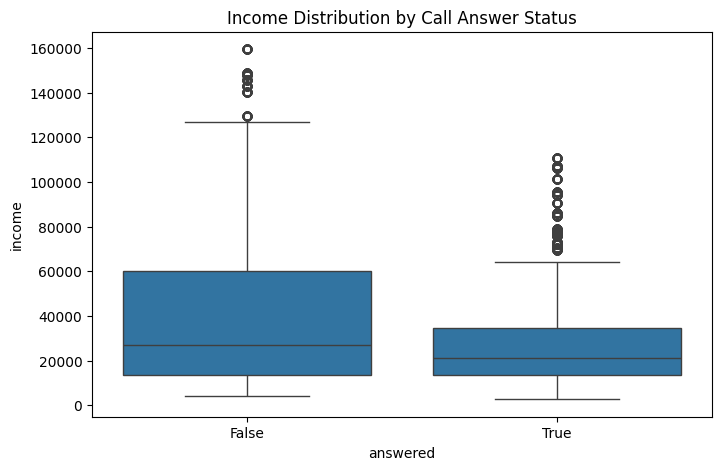

In [21]:
# Chart 1 🔧
plt.figure(figsize=(8,5))
sns.boxplot(x='answered', y='income', data=df_clean)
plt.title('Income Distribution by Call Answer Status')
plt.show()

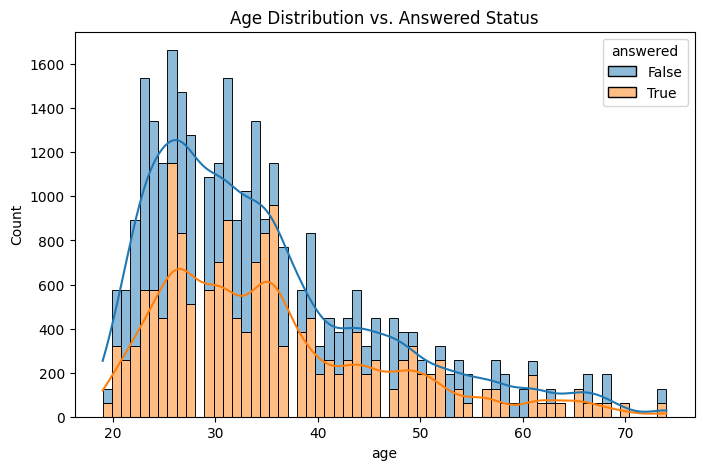

In [23]:
# Chart 2 🔧
plt.figure(figsize=(8,5))
sns.histplot(data=df_clean, x='age', hue='answered', multiple='stack', kde=True)
plt.title('Age Distribution vs. Answered Status')
plt.show()

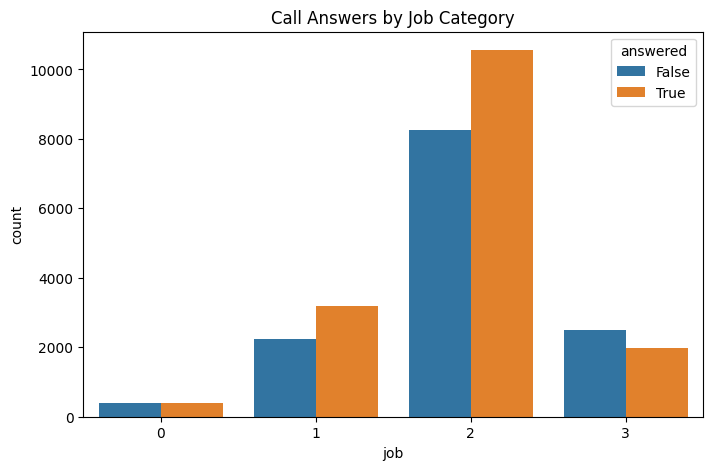

In [24]:
# Chart 3 🔧
plt.figure(figsize=(8,5))
sns.countplot(x='job', hue='answered', data=df_clean)
plt.title('Call Answers by Job Category')
plt.show()

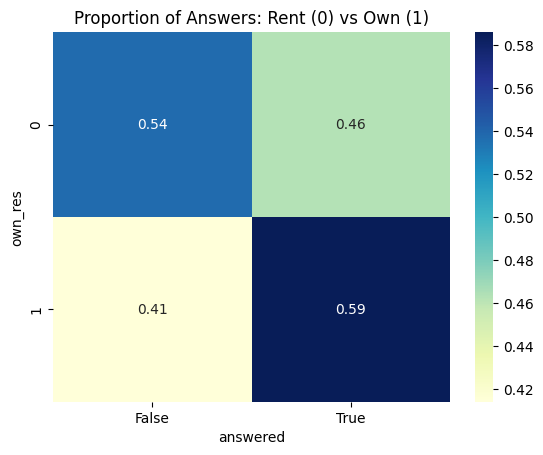

In [25]:
# Chart 4 🔧
ct = pd.crosstab(df_clean['own_res'], df_clean['answered'], normalize='index')
sns.heatmap(ct, annot=True, cmap='YlGnBu')
plt.title('Proportion of Answers: Rent (0) vs Own (1)')
plt.show()

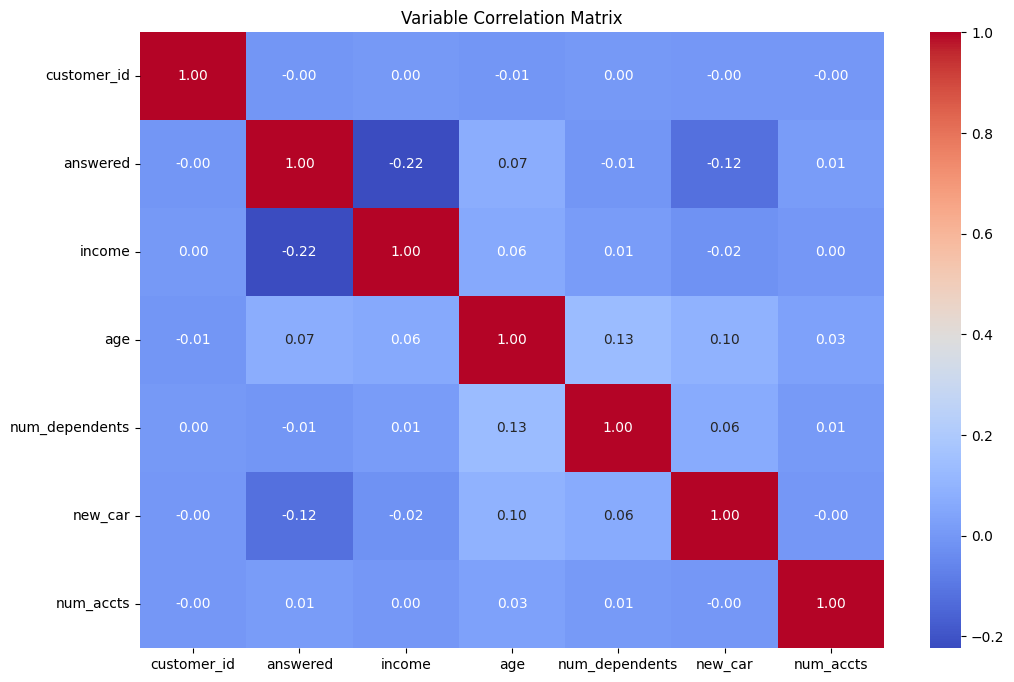

In [26]:
# Chart 5 🔧
plt.figure(figsize=(12,8))
sns.heatmap(df_clean.select_dtypes(include=['number', 'bool']).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Variable Correlation Matrix')
plt.show()

## Step 4: Modeling

### 4.1: Calculate the base probability of answering

If we use no model at all, how good is our chance of predicting someone leaving?  Use a calculation to find the chances of someone leaving.

In [34]:
#get the default probability 🔧
base_prob = df_clean['answered'].mean()

print(f"Base Probability of answering: {base_prob:.2%}")

Base Probability of answering: 54.67%


### 4.2: Split the training and testing datasets

- split df_clean using train_test_split function
- all variables except answered should be in the x variable
- answered is in the y variable


In [35]:
# Split data into training and testing sets 🔧
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['answered', 'customer_id'])
y = df_clean['answered']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 20647
Testing set size: 8849


### 4.3: Create a Decision Tree
- Use all available attributes (except those that were eliminated in step 3)
- It is recommended to use the type "entropy" and a max_depth of 4

In [36]:
#create a tree  🔧
from sklearn.tree import DecisionTreeClassifier, plot_tree


clf = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

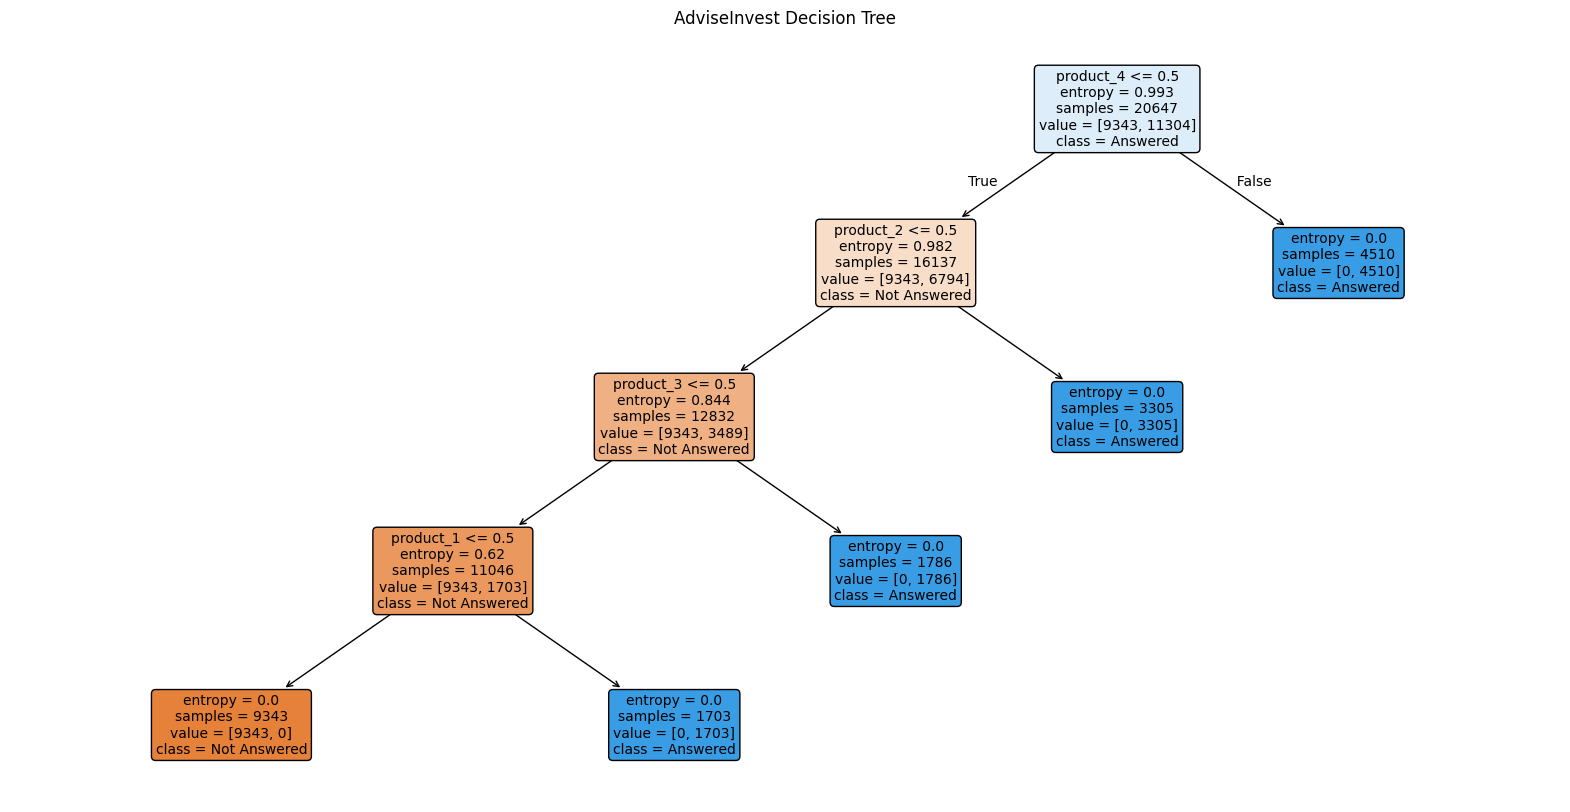

In [37]:
#display (visualize) the tree 🔧
plt.figure(figsize=(20,10))
plot_tree(clf,
          feature_names=list(X.columns),
          class_names=['Not Answered', 'Answered'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("AdviseInvest Decision Tree")
plt.show()

### 4.4: What is the accuracy?

This should be better than the base probability, or you have failed in your objective

In [38]:
#calculate the probability for your tree 🔧
from sklearn.metrics import accuracy_score

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Decision Tree Accuracy: {accuracy: .2%}")
print(f"Improvement over Base: {(accuracy - base_prob): .2%}")

Decision Tree Accuracy:  100.00%
Improvement over Base:  45.33%


### 4.5: Create a confusion matrix

This will show false positives, true positives, etc.

In [39]:
#create a basic confusion matrix 🔧
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4028    0]
 [   0 4821]]


Create a more visual, interpretable version of the matrix

In [40]:
#Create a beautiful matrix; hint - try using Seaborn Heatmap 🔧
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4028    0]
 [   0 4821]]


# Step 5: Evaluate the Model

**Assumptions**

One of the simplifying assumptions we will make in this project is that all the customers who answer the phone will purchase a product. (This assumption is actually verified by the data.) To model "answered" in this case is therefore equivalent to modeling "purchased."

There are costs and benefits in this case. We will assume that customers purchase a product for 100 dollars. This was the average cost of AdviseInvest products, according to the Director of Sales.  Also, as we learned in the interview, the agent time to make the sale is worth 25 dollars. Profit would therefore be \$75 dollars for an answered call and a purchase. In sum:

**Benefit**: True positive. The customer is predicted to answer, does answer, and purchases a product for 100 dollars for a profit of 100 - 25 = 75.

**Cost**: False positive. The customer is predicted to answer, but does not answer, so there is a loss of 25. (We assume the agent cannot schedule another call at the last minute, or spends the entire time slot trying to make the call.)

When you create a calculation you can use:
- True answered * 75 -> These people purchased
- False answered * 25 -> You can't schedule another call

For this exercise, we propose that customers who are not predicted to answer will not be called, so there would be no benefits and no costs for them.  

### 5.1 Calculate the Profit Using the Model

In [41]:
# Write a calcuation for the profit from your model 🔧
tp = 4821
fp = 0

model_profit = (tp * 75) - (fp * 25)

print(f"Total Profit using the Model: ${model_profit:,}")

Total Profit using the Model: $361,575


### 5.2 Compare to the Default Profit

How much profit (revenue - costs) could be expected if all customers are called? We can consider this a baseline case for profit since it does not require a model.

In other words, to calculate profit in this baseline scenario treat the customers who answer as true positives treat the customers who do not answer as false positives.

In [42]:
#Write a calculation for the overall profit without using the model (default) 🔧
total_answered = 4821
total_not_answered = 4028

default_profit = (total_answered * 75) - (total_not_answered * 25)

print(f"Total Profit without the Model: ${default_profit:,}")
print(f"Value added by the model: ${model_profit - default_profit:,}")

Total Profit without the Model: $260,875
Value added by the model: $100,700


### 5.3 Tune the Model
- Adjust the size or shape of the tree, then test the accuracy
- Keep changing these parameters until you end up with a tree with accuracy that is better than the initial model

In [43]:
# Create a new version of the tree with new parameters 🔧
clf_tuned = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf_tuned.fit(X_train, y_train)

y_pred_tuned = clf_tuned.predict(X_test)
new_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"Tuned Decision Tree Accuracy: {new_accuracy:.2%}")

Tuned Decision Tree Accuracy: 91.77%


In [44]:
# Calculate a new probability 🔧
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"Original Model Accuracy: {accuracy:.2%}")
print(f"Tuned Model Accuracy: {tuned_accuracy:.2%}")

Original Model Accuracy: 100.00%
Tuned Model Accuracy: 91.77%


### 5.4 Apply the Model to New Customers
- Import the "adviseinvest_new_customer_data.csv" file
- Using the tree model, predict each customer for the target variable  by feeding the new customer data into the model

In [47]:
#Import new customer data into a new data frame 🔧
df_new = pd.read_csv('adviseinvest_historical_data (1).csv')

X_new = df_new.drop(columns=['customer_id'])

print("New customer data loaded and prepped!")

New customer data loaded and prepped!


In [48]:
#Predict the number of customers who will be yes/no for the target variable 🔧
new_predictions = clf.predict(X_new)

df_new['predicted_answer'] = new_predictions

prediction_counts = df_new['predicted_answer'].value_counts()

print("Predictions complete!")
print(f"Customers predicted to answer: {prediction_counts.get(True, 0)}")
print(f"Customers predicted to ignore: {prediction_counts.get(False, 0)}")

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- answered
- chk_acct
- female
- job
- mobile
- ...
Feature names seen at fit time, yet now missing:
- chk_acct_1
- chk_acct_2
- chk_acct_3
- female_1
- female_M
- ...


# Step 6: Conclusion
### 6.1: Did we improve our profit using the model?  

Write your conclusion notes below:  🔧

### 6.2: How could the model be utilized by the business?

Write your recommendations below:  🔧

The model increaserd profitqblilty by almost 100,000.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [50]:
!jupyter nbconvert --to html "assignment_10_classification.ipynb"

[NbConvertApp] Converting notebook assignment_10_classification.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 756873 bytes to assignment_10_classification.html
